##                                                                         E- COMMERCE CUSTOMER SEGMENTATION AND PREDICTION.

In [185]:
!pip install pandas numpy matplotlib seaborn scikit-learn


Importing Libraries.

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
df=pd.read_csv('data.csv', encoding='latin1')

Loading the dataset.

In [188]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France


## EDA and Preprocesing.

In [189]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


Shows first 5 rows of the dataset.

In [190]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Mentions column names.

In [191]:
df.shape

(541909, 8)

Shows there are 541909 rows and 8 columns.

In [192]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Shows the type of data in the dataset.

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Shows there are 5 categorical columns and 3 numeric columns in the dataset.

In [194]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Shows the statistical distribution of data.

In [195]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Shows there are 1454 missing values in desciption column and 135080 missing values in customerid column.

In [196]:
df=df.dropna(subset=['CustomerID'])

As there are huge number of missing values in customerid column so i droped them.

In [197]:
df.shape

(406829, 8)

In [198]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [199]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

As there were negative and zero prices so we cleaned them by removing negative price and zero quantity

In [200]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France


In [201]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

As we need total price for calculating RFM so we created total price column by using quantity and unitprice.

In [202]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [203]:
df.shape

(397884, 9)

### RFM CALCULATION

In [204]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', errors='coerce')

Firstly i converted date column for calculating thr recency.

In [205]:

reference_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)


I defined the refernce date for calculating RFM.

In [206]:
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(reference_date-x.max()).days,
    'InvoiceNo':'nunique',
    'TotalPrice':'sum'
})

As we have to claculate recency,frequency and monetary factors using customerid, invoicedate, totalprice so here i used lambda funtion calculating rfm table in one go.

In [207]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

Here i renamed the column names with invoicedate, invoiceno, totalprice to recency,frequency, monetary for rfm analysis.

In [208]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# EDA

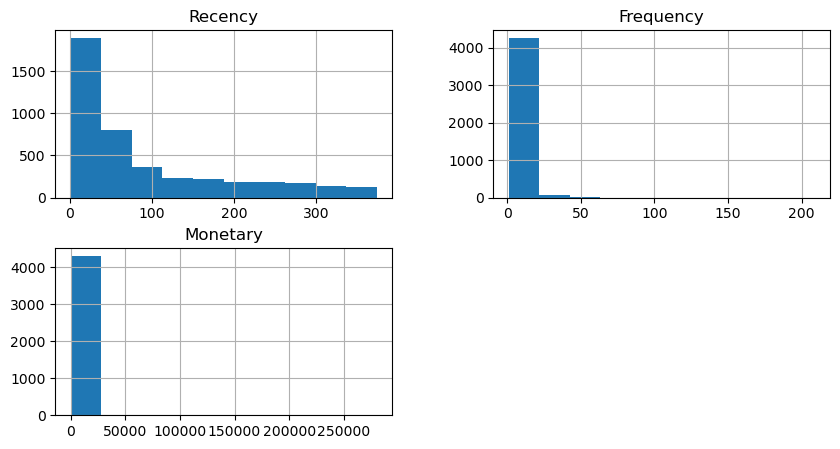

In [209]:
rfm.hist(figsize=(10,5))
plt.show()

Histplot shows the time intervals of customers purchase, frequent behaviour of customer for peoducts and monetary shows total amount spent by the customer.

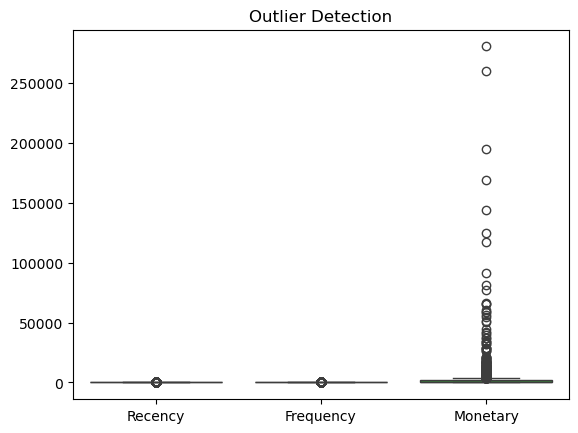

In [210]:
sns.boxplot(data=rfm)
plt.title('Outlier Detection')
plt.show()

Here we have extreme outliers in monetray terms

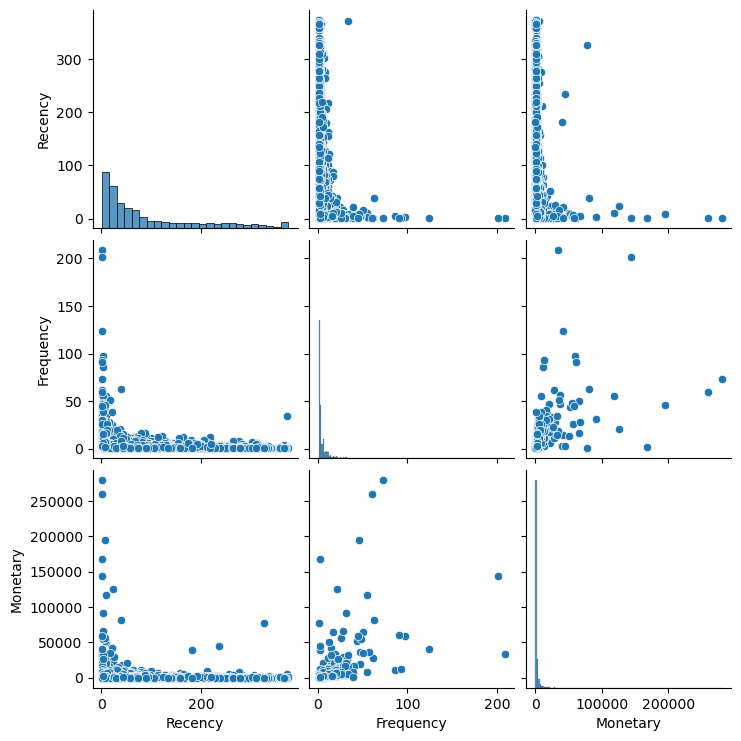

In [211]:
sns.pairplot(rfm)
plt.show()

Here we can see all visual representation of all numeric columns.

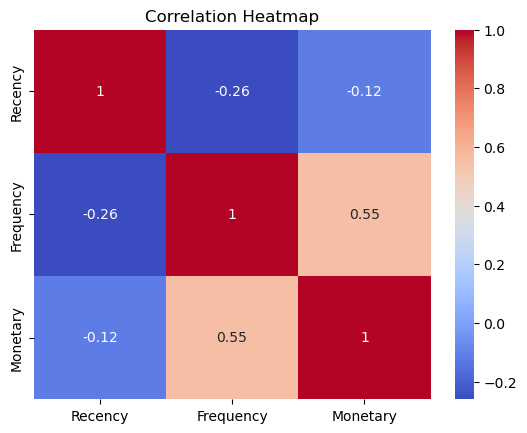

In [212]:
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Here we can see the correlation between the RFM  

# OUTLIERS

In [213]:
original_shape = rfm.shape




As there are huge outliers so we are using IQR technique to remove them.

In [214]:
Q1 = rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)
IQR = Q3 - Q1

In [215]:
rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_filtered = rfm[~((rfm_numeric < (Q1 - 1.5 * IQR)) | (rfm_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

In [216]:
print("Before:", original_shape)
print("After:", rfm_filtered.shape)

Before: (4338, 3)
After: (3710, 3)


Comparing before and after treating outliers with the help of shape

In [217]:
rfm = rfm_filtered.copy()

In [218]:
print("Before:", original_shape)
print("After:", rfm.shape)

Before: (4338, 3)
After: (3710, 3)


Here we have replaced the shape of data after outlier treatment.

# FEATURE SCALING

In [219]:
from sklearn.preprocessing import StandardScaler

In [220]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

In [221]:
print(np.mean(rfm_scaled, axis=0))
print(np.std(rfm_scaled, axis=0))

[ 1.91520953e-17 -6.60747288e-17 -1.14912572e-17]
[1. 1. 1.]


In [222]:
print(rfm_scaled[:5])

[[-0.17040243  0.53078448  1.11862155]
 [-0.80034566 -0.83735616  1.06982647]
 [ 2.47310931 -0.83735616 -0.67980119]
 [-0.60911289  2.35497202  1.99002378]
 [ 1.28071678 -0.83735616 -0.98149716]]


As the data qas imbalanced by scaling the RFM features have mean of 0 and std deviation of 1 which shows algorithm treats each metric with equal weight.

## K-MEANS CLUSTERING

In [223]:
from sklearn.cluster import KMeans

In [224]:
df = df.dropna()
wcss=[]
for i in range(1,11):
  kmeans=KMeans (n_clusters=i,random_state=42)
  kmeans.fit(rfm_scaled)
  wcss.append(kmeans.inertia_)


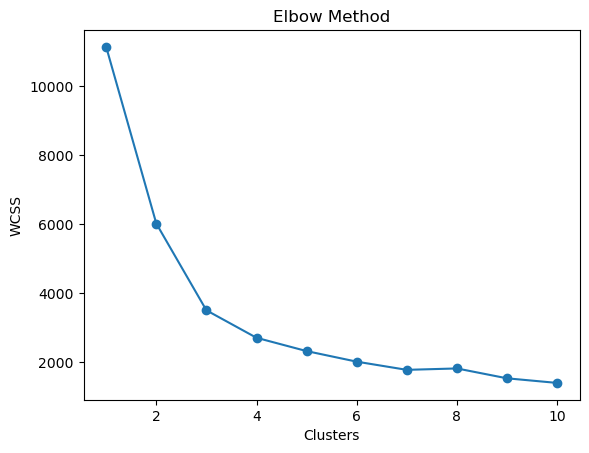

In [225]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Here i have used the elbow method to showcase the behaviour of cluster as per the RFM segments.

In [226]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [227]:
print(rfm['Cluster'].value_counts())

Cluster
0    1489
2     897
1     875
3     449
Name: count, dtype: int64


Here is the total value count of all clusters in numeric form

In [228]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1
12352.0,36,8,2506.04,3
12353.0,204,1,89.00,1


## SEGMENT LABELING

In [229]:
def segment(row):
    if row['Monetary'] > 1000 and row['Frequency'] > 5:
        return 'VIP Customers'
    elif row['Frequency'] > 3:
        return 'Loyal/Regular'
    elif row['Recency'] > 100:
        return 'Hibernating/Lost'
    else:
        return 'New/Occasional'

rfm['Segment'] = rfm.apply(segment, axis=1)

Here i have assigned the segment names according to the clusters formed dividing them to different categories.

In [230]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12348.0,75,4,1797.24,2,Loyal/Regular
12349.0,19,1,1757.55,2,New/Occasional
12350.0,310,1,334.40,1,Hibernating/Lost
12352.0,36,8,2506.04,3,VIP Customers
12353.0,204,1,89.00,1,Hibernating/Lost
...,...,...,...,...,...
18278.0,74,1,173.90,0,New/Occasional
18280.0,278,1,180.60,1,Hibernating/Lost
18281.0,181,1,80.82,1,Hibernating/Lost


# SILHOUTTE SCORE

In [231]:
from sklearn.metrics import silhouette_score

In [232]:
silhouette_scores=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  labels=kmeans.fit_predict(rfm_scaled)
  score=silhouette_score(rfm_scaled,labels)
  silhouette_scores.append(score)

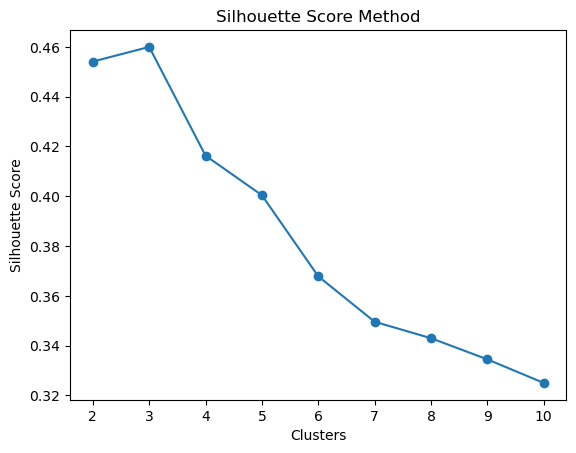

In [233]:
plt.plot(range(2,11),silhouette_scores,marker='o')
plt.xlabel('Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.show()

In [234]:
print('best silhoutte score is',max(silhouette_scores))

best silhoutte score is 0.45995897149112314


Here i have used silhoutte scoring to get the accuracy for getting accurate results.

#  HEIRARCHICAL CLUSTERING

In [235]:
from scipy.cluster.hierarchy import linkage, dendrogram



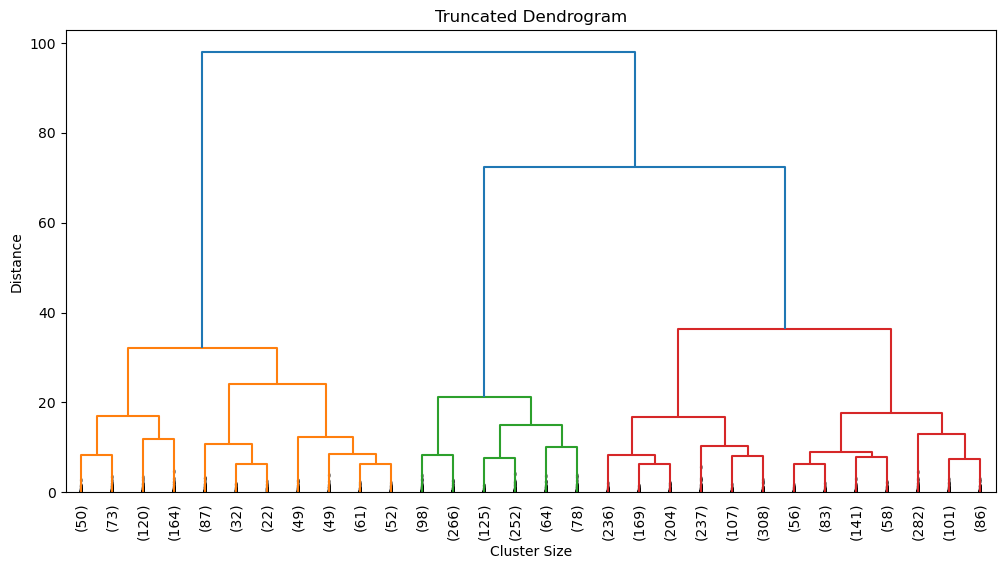

In [236]:
linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90.,
           leaf_font_size=10.,
           show_contracted=True)

plt.title('Truncated Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

Here i have used hierarchical clustering to get the best accuracy using dendogram.

## DBSCAN

In [237]:
from sklearn.cluster import DBSCAN

In [238]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
rfm['DBSCAN_Cluster']=dbscan.fit_predict(rfm_scaled)


In [239]:
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    3672
-1      38
Name: count, dtype: int64


As i have used k means so dbscan is showing the outlier involved in monetary segment using eps to avoid the skewness in data.

# PCA

In [240]:
from sklearn.decomposition import PCA

In [241]:
pca=PCA(n_components=2)
rfm_pca=pca.fit_transform(rfm_scaled)

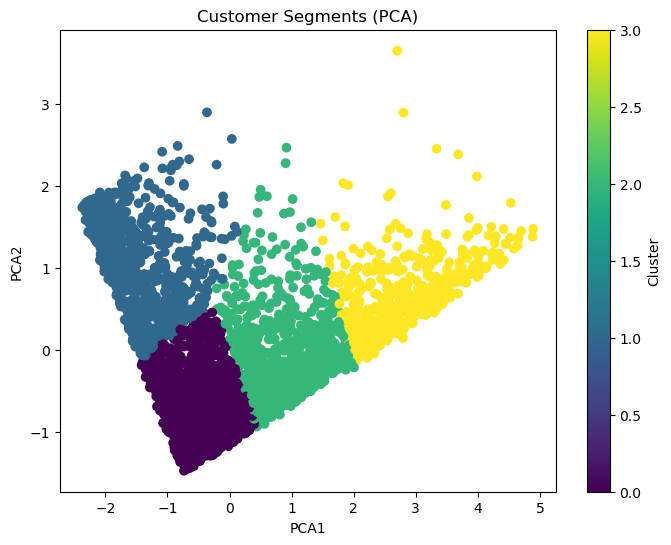

In [242]:
plt.figure(figsize=(8,6))
plt.scatter(rfm_pca[:,0],rfm_pca[:,1],c=rfm['Cluster'],cmap='viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Customer Segments (PCA)')
plt.colorbar(label='Cluster')
plt.show()

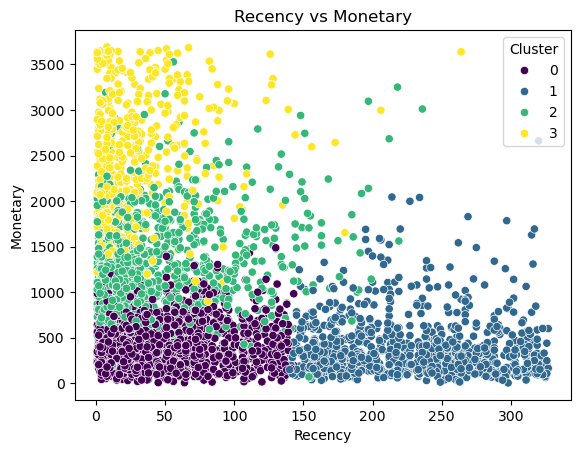

In [243]:
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.title('Recency vs Monetary')
plt.show()

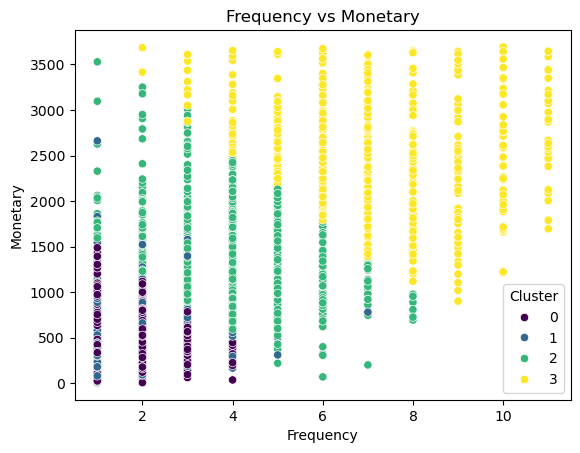

In [244]:
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.title('Frequency vs Monetary')
plt.show()

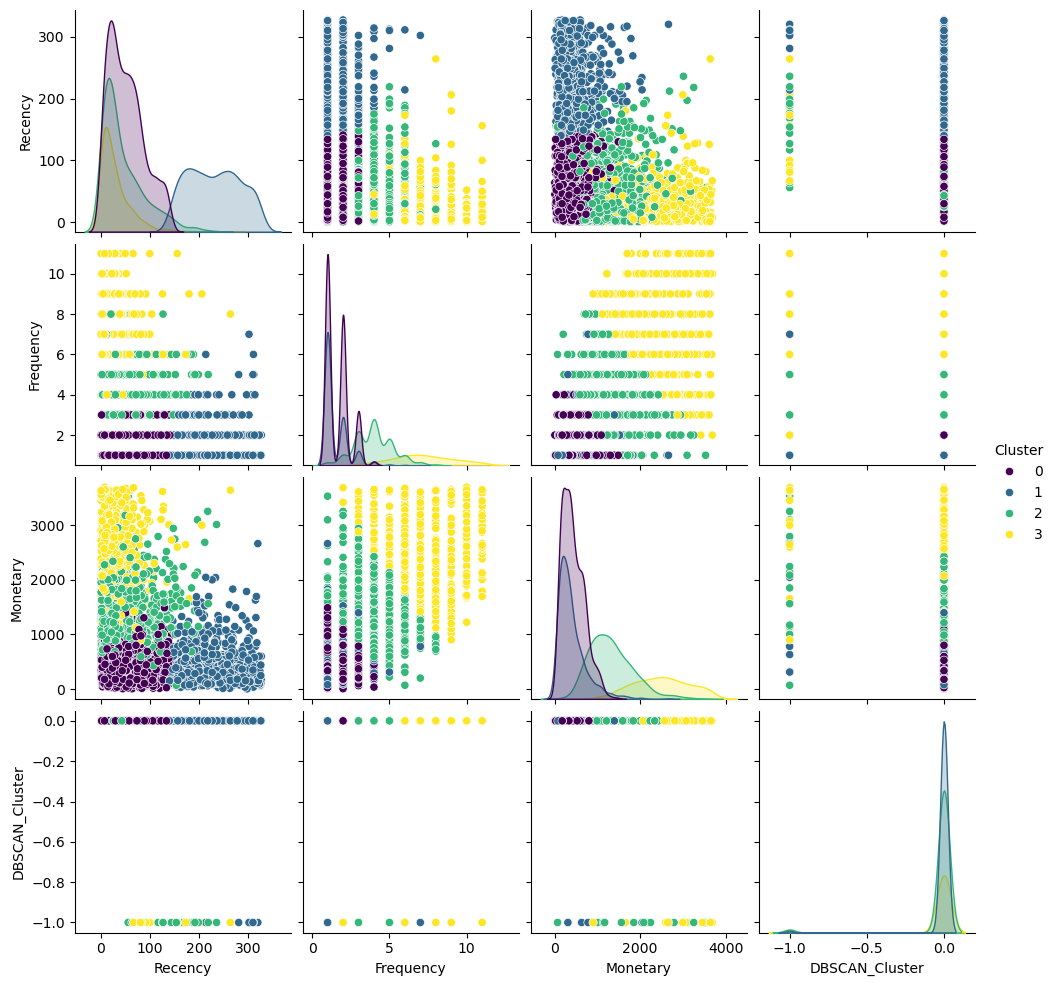

In [245]:
sns.pairplot(rfm, hue='Cluster', palette='viridis')
plt.show()

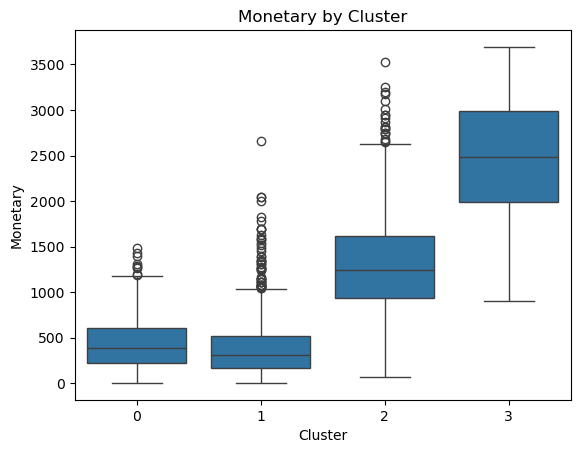

In [246]:
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title('Monetary by Cluster')
plt.show()

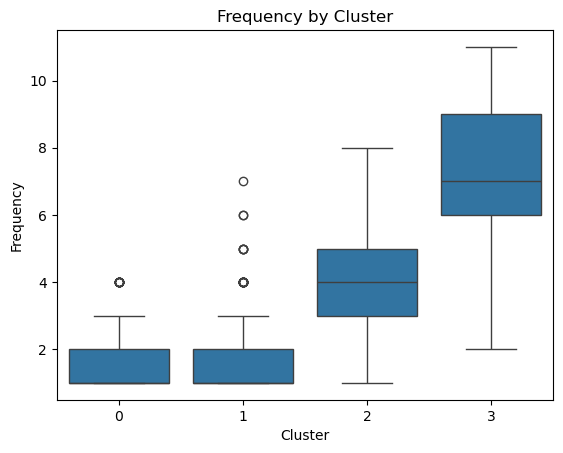

In [247]:
sns.boxplot(x='Cluster', y='Frequency', data=rfm)
plt.title('Frequency by Cluster')
plt.show()

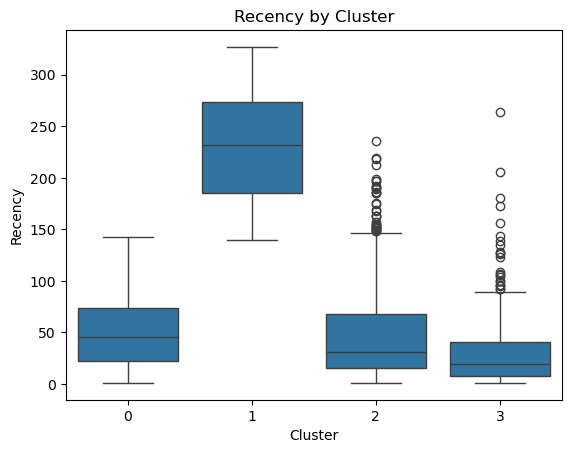

In [248]:
sns.boxplot(x='Cluster', y='Recency', data=rfm)
plt.title('Recency by Cluster')
plt.show()

In [249]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0         51.859637   1.644056   431.621620
1        230.848000   1.482286   401.971074
2         46.410256   3.966555  1315.476981
3         30.309577   7.169265  2489.268508


Churn prediction for target variable.

In [250]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

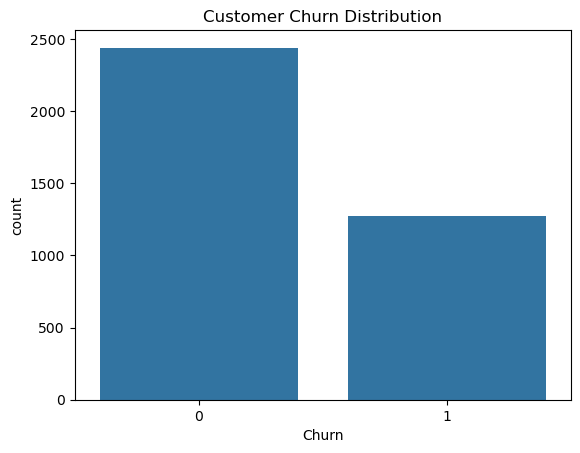

In [251]:
sns.countplot(x='Churn', data=rfm)
plt.title("Customer Churn Distribution")
plt.show()

In [252]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment,DBSCAN_Cluster,Churn
CustomerID,,,,,,,
12348.0,75,4,1797.24,2,Loyal/Regular,0,0
12349.0,19,1,1757.55,2,New/Occasional,0,0
12350.0,310,1,334.40,1,Hibernating/Lost,0,1
12352.0,36,8,2506.04,3,VIP Customers,0,0
12353.0,204,1,89.00,1,Hibernating/Lost,0,1
...,...,...,...,...,...,...,...
18278.0,74,1,173.90,0,New/Occasional,0,0
18280.0,278,1,180.60,1,Hibernating/Lost,0,1
18281.0,181,1,80.82,1,Hibernating/Lost,0,1


In [253]:
country_summary = df.groupby('Country').agg({
    'TotalPrice': 'sum',
    'CustomerID': 'nunique',
    'InvoiceNo': 'nunique'
}).reset_index()

country_summary.columns = ['Country', 'TotalRevenue', 'TotalCustomers', 'TotalOrders']

country_summary = country_summary.sort_values(by='TotalRevenue', ascending=False)
country_summary.head()

,Country,TotalRevenue,TotalCustomers,TotalOrders
35,United Kingdom,7308391.554,3920,16646
23,Netherlands,285446.340,9,94
10,EIRE,265545.900,3,260
14,Germany,228867.140,94,457
13,France,209024.050,87,389


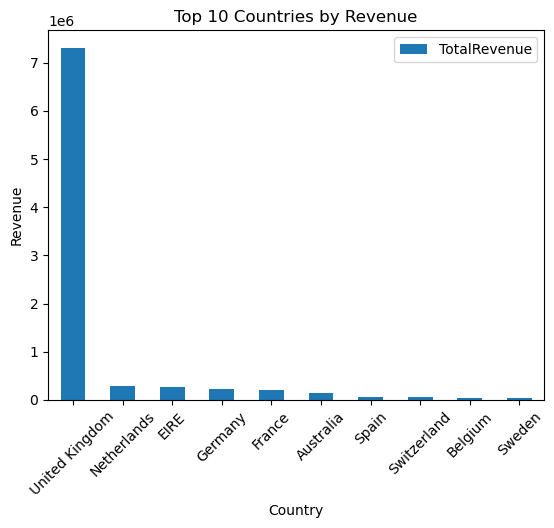

In [254]:
country_summary.head(10).plot(
    x='Country',
    y='TotalRevenue',
    kind='bar'
)

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

United Kingdom has the most customers

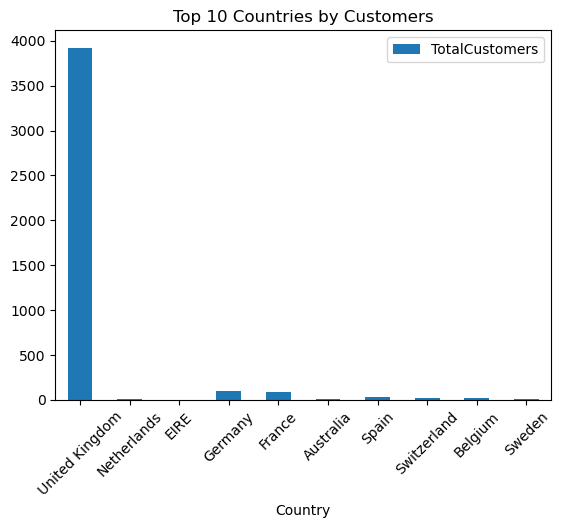

In [255]:
country_summary.head(10).plot(
    x='Country',
    y='TotalCustomers',
    kind='bar'
)

plt.title("Top 10 Countries by Customers")
plt.xticks(rotation=45)
plt.show()

# TRAIN-TEST SPLIT

Splitting the data for training and testing.

In [256]:
from sklearn.model_selection import train_test_split

In [257]:
X=rfm[['Recency','Frequency','Monetary']]
y=rfm['Churn']

In [258]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment,DBSCAN_Cluster,Churn
CustomerID,,,,,,,
12348.0,75,4,1797.24,2,Loyal/Regular,0,0
12349.0,19,1,1757.55,2,New/Occasional,0,0
12350.0,310,1,334.40,1,Hibernating/Lost,0,1
12352.0,36,8,2506.04,3,VIP Customers,0,0
12353.0,204,1,89.00,1,Hibernating/Lost,0,1
...,...,...,...,...,...,...,...
18278.0,74,1,173.90,0,New/Occasional,0,0
18280.0,278,1,180.60,1,Hibernating/Lost,0,1
18281.0,181,1,80.82,1,Hibernating/Lost,0,1


In [259]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [260]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2968, 3), (742, 3), (2968,), (742,))

## RANDOM FOREST

In [261]:
from sklearn.ensemble import RandomForestClassifier

In [262]:
df = df.dropna()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [263]:
rf_pred = rf_model.predict(X_test)

In [264]:
from sklearn.metrics import confusion_matrix, classification_report

print("Random Forest Results:\n")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Results:

[[494   0]
 [  0 248]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       494
           1       1.00      1.00      1.00       248

    accuracy                           1.00       742
   macro avg       1.00      1.00      1.00       742
weighted avg       1.00      1.00      1.00       742



## Logistic Regression

In [265]:
from sklearn.linear_model import LogisticRegression


In [266]:
df = df.dropna()
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [267]:
y_pred=lr.predict(X_test)

In [268]:
X_test

,Recency,Frequency,Monetary
CustomerID,,,
15216.0,88,1,96.60
14087.0,3,1,194.42
14218.0,43,1,169.48
13639.0,74,1,1033.34
13655.0,114,2,932.97
...,...,...,...
16387.0,323,1,94.36
13343.0,178,1,353.43
17557.0,14,3,541.46


In [269]:
from sklearn.metrics import accuracy_score
print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       494
           1       1.00      1.00      1.00       248

    accuracy                           1.00       742
   macro avg       1.00      1.00      1.00       742
weighted avg       1.00      1.00      1.00       742



# FEATURE IMPORTANCE

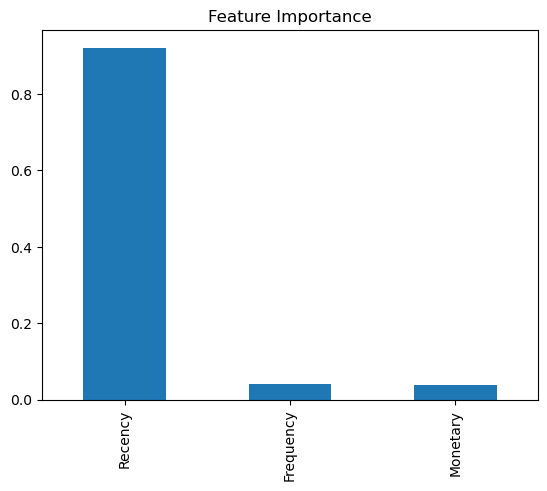

In [270]:
importance=pd.Series(rf_model.feature_importances_,index=X.columns)
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

Here feature importance is showcasing the types of features impacting the churn.

In [271]:
import joblib

In [272]:
joblib.dump(kmeans,'kmeans_model.pkl')
joblib.dump(rf_model,'rf_model.pkl')


['rf_model.pkl']

Saving the model.

In [273]:
print("Models saved successfully!")

Models saved successfully!


In [274]:
rfm.to_csv('rfm_dashboard.csv')

Exportiong the dataset to power bi

# CONCLUSION:
In this project, i used RFM analysis to segment customers into meaningful groups such as VIP, Loyal, New, and Hibernating customers using K-Means clustering.
For churn prediction, Logistic Regression and Random Forest models were implemented. The Random Forest model achieved 100% accuracy on the test data and outperformed Logistic Regression.
The high accuracy is due to the strong influence of Recency in defining churn, making it the most important feature in prediction.
These insights help businesses identify high-value customers and take actions to reduce churn and improve customer retention.



